<a href="https://colab.research.google.com/github/TKhahahah/House_price/blob/main/House_price.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import data

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np

In [86]:
#test dataset
test_df = pd.read_csv('/content/drive/MyDrive/FJ/house_price/test.csv')
test_df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


In [87]:
#train dataset
train_df = pd.read_csv('/content/drive/MyDrive/FJ/house_price/train.csv')
train_df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


#EDA

In [5]:
train_df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [6]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [11]:
train_df.isnull().sum()

,0
Id,0
MSSubClass,0
MSZoning,0
LotFrontage,259
LotArea,0
...,...
MoSold,0
YrSold,0
SaleType,0
SaleCondition,0


In [12]:
for i in train_df.isnull().sum():
  print(i)

0
0
0
259
0
0
1369
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
872
8
0
0
0
37
37
38
37
0
38
0
0
0
0
0
0
1
0
0
0
0
0
0
0
0
0
0
0
0
0
0
690
81
81
81
0
0
81
81
0
0
0
0
0
0
0
1453
1179
1406
0
0
0
0
0
0


In [14]:
nan_columns = train_df.isnull().sum()
nan_columns = nan_columns[nan_columns > 0]
print(nan_columns)

LotFrontage      259
Alley           1369
MasVnrType       872
MasVnrArea         8
BsmtQual          37
BsmtCond          37
BsmtExposure      38
BsmtFinType1      37
BsmtFinType2      38
Electrical         1
FireplaceQu      690
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
PoolQC          1453
Fence           1179
MiscFeature     1406
dtype: int64


NaN in each row doesn't mean it doesn't has any data but it means itself (GarageCond - No Garage
)

Mean
LotFrontage , MasVnrArea,

Mode
GarageYrBlt

In [30]:
clean_train_df = train_df.copy()

# Fill LotFrontage and MasVnrArea with their respective means
clean_train_df['LotFrontage'] = clean_train_df['LotFrontage'].fillna(train_df['LotFrontage'].mean())
clean_train_df['MasVnrArea'] = clean_train_df['MasVnrArea'].fillna(train_df['MasVnrArea'].mean())

# Fill GarageYrBlt with its mode (taking the first mode if there are multiple)
clean_train_df['GarageYrBlt'] = clean_train_df['GarageYrBlt'].fillna(train_df['GarageYrBlt'].mode()[0])

clean_train_df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## Data Analysis

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

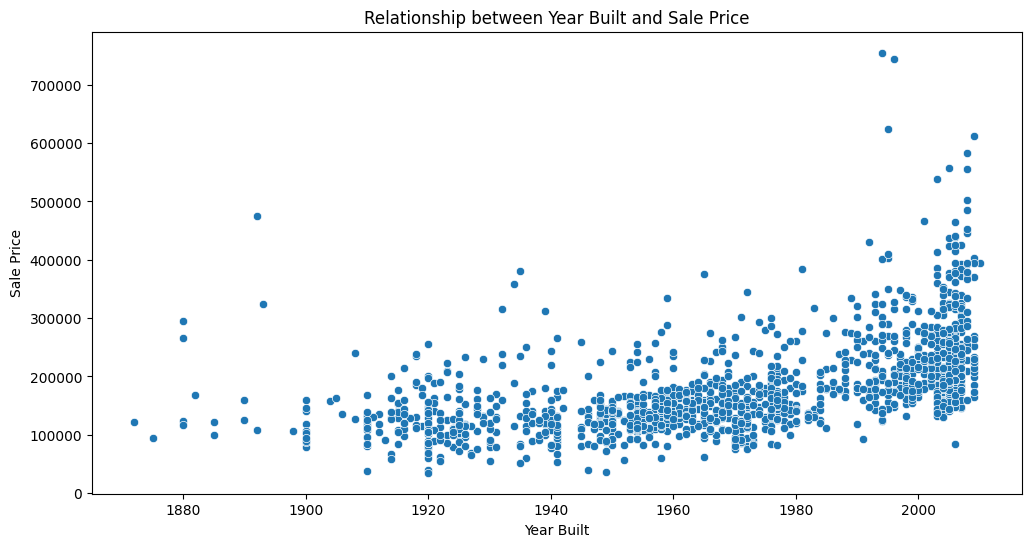

In [43]:
plt.figure(figsize=(12, 6))
sns.scatterplot(x=clean_train_df['YearBuilt'], y=clean_train_df['SalePrice'])
plt.xlabel('Year Built')
plt.ylabel('Sale Price')
plt.title('Relationship between Year Built and Sale Price')
plt.show()

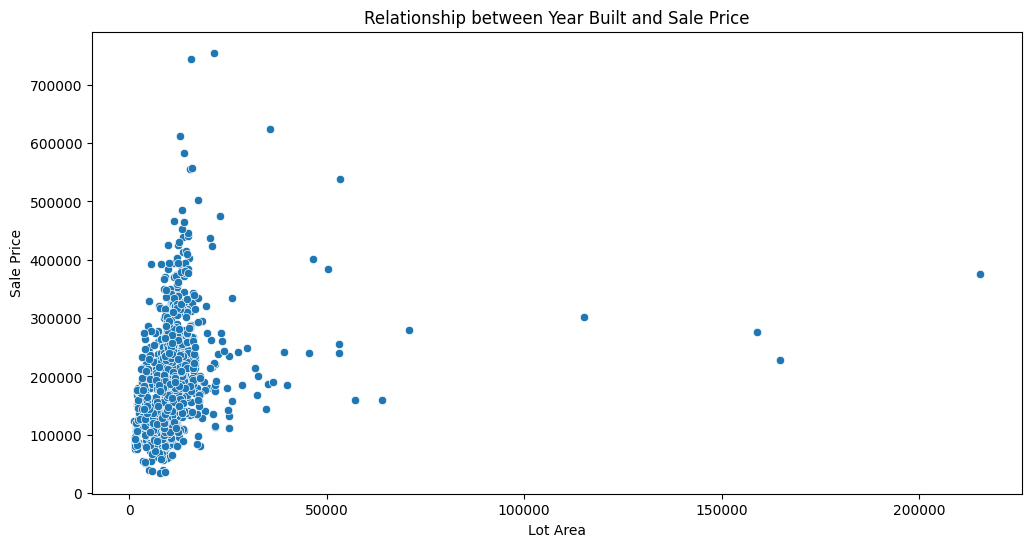

In [47]:
plt.figure(figsize=(12, 6))
sns.scatterplot(x=clean_train_df['LotArea'], y=clean_train_df['SalePrice'])
plt.xlabel('Lot Area')
plt.ylabel('Sale Price')
plt.title('Relationship between Year Built and Sale Price')
plt.show()

In [48]:
from sklearn.preprocessing import OneHotEncoder

In [49]:
encode_data = pd.get_dummies(clean_train_df)
encode_data.head()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_Abnorml,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,1,60,65.0,8450,7,5,2003,2003,196.0,706,...,False,False,False,True,False,False,False,False,True,False
1,2,20,80.0,9600,6,8,1976,1976,0.0,978,...,False,False,False,True,False,False,False,False,True,False
2,3,60,68.0,11250,7,5,2001,2002,162.0,486,...,False,False,False,True,False,False,False,False,True,False
3,4,70,60.0,9550,7,5,1915,1970,0.0,216,...,False,False,False,True,True,False,False,False,False,False
4,5,60,84.0,14260,8,5,2000,2000,350.0,655,...,False,False,False,True,False,False,False,False,True,False


In [50]:
#split X and y
X = encode_data.drop('SalePrice', axis=1)
y = encode_data['SalePrice']

In [51]:
#Split train and test dataset
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [53]:
X_train

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_Abnorml,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
254,255,20,70.0,8400,5,6,1957,1957,0.0,922,...,False,False,False,True,False,False,False,False,True,False
1066,1067,60,59.0,7837,6,7,1993,1994,0.0,0,...,False,False,False,True,False,False,False,False,True,False
638,639,30,67.0,8777,5,7,1910,1950,0.0,0,...,False,False,False,True,False,False,False,False,True,False
799,800,50,60.0,7200,5,7,1937,1950,252.0,569,...,False,False,False,True,False,False,False,False,True,False
380,381,50,50.0,5000,5,6,1924,1950,0.0,218,...,False,False,False,True,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1095,1096,20,78.0,9317,6,5,2006,2006,0.0,24,...,False,False,False,True,False,False,False,False,True,False
1130,1131,50,65.0,7804,4,3,1928,1950,0.0,622,...,False,False,False,True,False,False,False,False,True,False
1294,1295,20,60.0,8172,5,7,1955,1990,0.0,167,...,False,False,False,True,False,False,False,False,True,False
860,861,50,55.0,7642,7,8,1918,1998,0.0,0,...,False,False,False,True,False,False,False,False,True,False


In [54]:
#Standardize
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [55]:
X_train_scaled

array([[-1.11928402, -0.8667643 , -0.01288179, ..., -0.12510865,
         0.46001984, -0.30263639],
       [ 0.79046412,  0.07410996, -0.5027726 , ..., -0.12510865,
         0.46001984, -0.30263639],
       [-0.21615189, -0.63154574, -0.14648837, ..., -0.12510865,
         0.46001984, -0.30263639],
       ...,
       [ 1.32669882, -0.8667643 , -0.45823707, ..., -0.12510865,
         0.46001984, -0.30263639],
       [ 0.30597137, -0.16110861, -0.68091471, ..., -0.12510865,
         0.46001984, -0.30263639],
       [ 0.93157852,  1.48542135, -0.76998577, ..., -0.12510865,
         0.46001984, -0.30263639]])

#Model

In [61]:
#Ridge regression
from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import RandomizedSearchCV

##Ridge Regression

In [57]:
ridgeReg = Ridge(alpha=5)

In [58]:
ridgeReg.fit(X_train_scaled, y_train)

Ridge(alpha=5)

In [59]:
#train and test score for ridge regression
print(ridgeReg.score(X_train_scaled, y_train))
print(ridgeReg.score(X_test_scaled, y_test))

0.9370598287310796
0.895014948472164


<Axes: ylabel='SalePrice'>

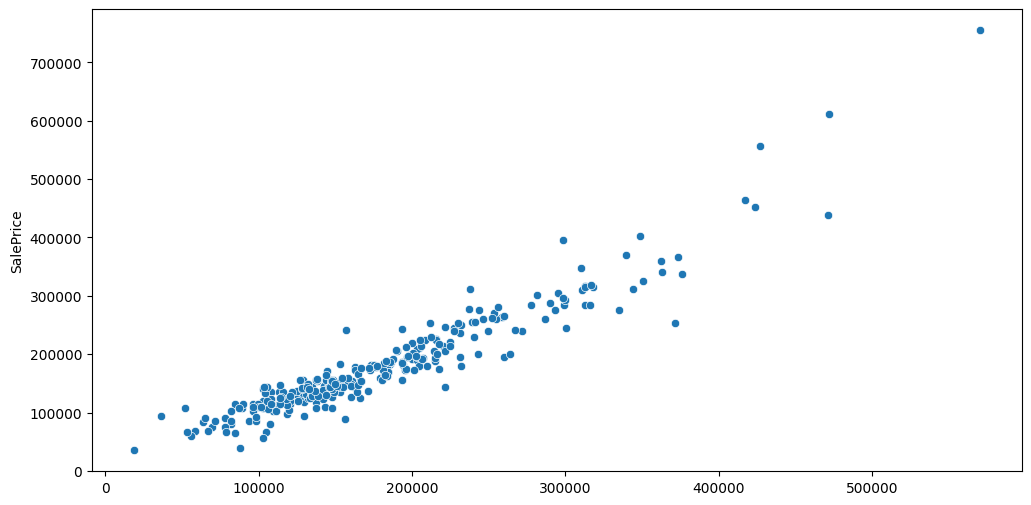

In [73]:
plt.figure(figsize=(12, 6))
sns.scatterplot(x=ridgeReg.predict(X_test_scaled), y=y_test)

##Lasso

In [64]:
lasso = Lasso(alpha=5)

In [65]:
lasso.fit(X_train_scaled, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.737e+11, tolerance: 6.967e+08
  model = cd_fast.enet_coordinate_descent(


Lasso(alpha=5)

In [66]:
print(lasso.score(X_train_scaled, y_train))
print(lasso.score(X_test_scaled, y_test))

0.9378653987342009
0.8849665282024877


<Axes: ylabel='SalePrice'>

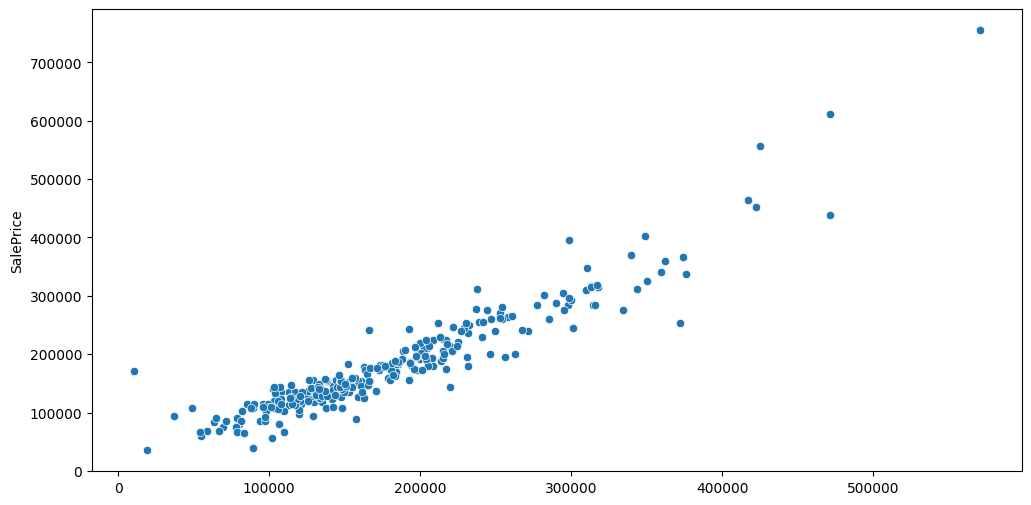

In [72]:
plt.figure(figsize=(12, 6))
sns.scatterplot(x=lasso.predict(X_test_scaled), y=y_test)

##XGB

In [79]:
import xgboost as xgb
xgb_model = xgb.XGBRegressor(objective="reg:squarederror", random_state=42)

In [80]:
xgb_model.fit(X_train_scaled, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [82]:
print(xgb_model.score(X_train_scaled, y_train))
print(xgb_model.score(X_test_scaled, y_test))

0.9997761845588684
0.9086991548538208


<Axes: ylabel='SalePrice'>

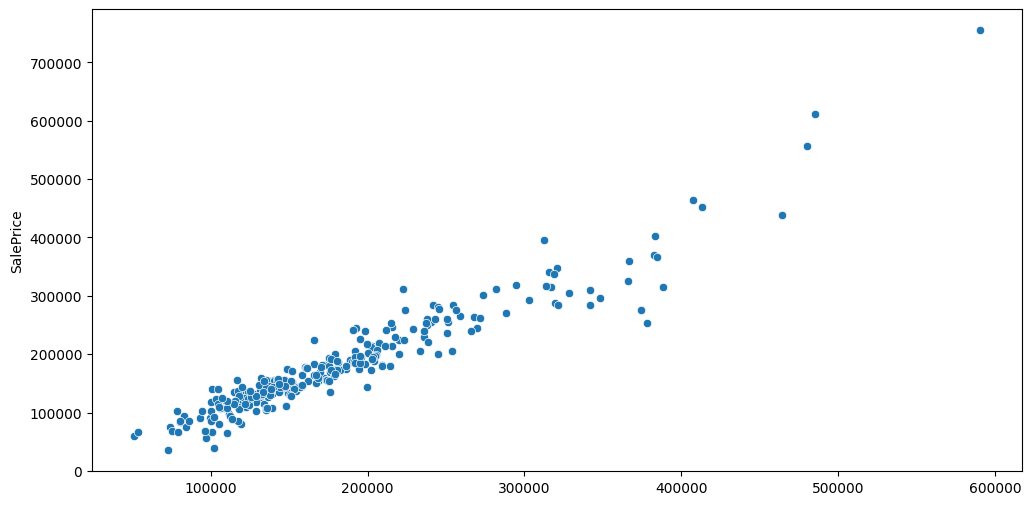

In [83]:
plt.figure(figsize=(12, 6))
sns.scatterplot(x=xgb_model.predict(X_test_scaled), y=y_test)

In [84]:
y_pred = xgb_model.predict(X_test_scaled)

#Test

In [74]:
#XGBoost Model
test_df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


In [89]:
# Make a copy of the test DataFrame to avoid modifying the original
clean_test_df = test_df.copy()

# --- Impute Missing Numeric Values with mean/median from train_df ---
# LotFrontage, MasVnrArea were imputed with mean in train_df
clean_test_df['LotFrontage'] = clean_test_df['LotFrontage'].fillna(train_df['LotFrontage'].mean())
clean_test_df['MasVnrArea'] = clean_test_df['MasVnrArea'].fillna(train_df['MasVnrArea'].mean())

# GarageYrBlt was imputed with mode in train_df
clean_test_df['GarageYrBlt'] = clean_test_df['GarageYrBlt'].fillna(train_df['GarageYrBlt'].mode()[0])

# For numerical columns that might have NaNs in test but not train, fill with 0 (assuming absence)
for col in ['BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath', 'GarageCars', 'GarageArea']:
    if col in clean_test_df.columns:
        clean_test_df[col] = clean_test_df[col].fillna(0)

# --- Impute Missing Categorical Values ---
# Columns where NaN means 'None' or 'No'
none_cols = ['Alley', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
             'FireplaceQu', 'PoolQC', 'Fence', 'MiscFeature', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'MasVnrType']
for col in none_cols:
    if col in clean_test_df.columns:
        clean_test_df[col] = clean_test_df[col].fillna('None')

# Columns where NaN means fill with mode from train_df
mode_cols = ['MSZoning', 'Utilities', 'Exterior1st', 'Exterior2nd', 'KitchenQual', 'Functional', 'SaleType', 'Electrical']
for col in mode_cols:
    if col in clean_test_df.columns:
        clean_test_df[col] = clean_test_df[col].fillna(train_df[col].mode()[0])

# One-hot encode categorical features for the test set
encode_test_df = pd.get_dummies(clean_test_df)

# Align columns - crucial for consistency between train and test sets
# Add missing columns (present in X_train but not in encode_test_df) and fill with 0
missing_cols = set(X_train.columns) - set(encode_test_df.columns)
for c in missing_cols:
    encode_test_df[c] = 0

# Drop columns present in encode_test_df but not in X_train
extra_cols = set(encode_test_df.columns) - set(X_train.columns)
encode_test_df = encode_test_df.drop(columns=list(extra_cols))

# Ensure the order of columns is the same as in X_train
encode_test_df = encode_test_df[X_train.columns]

# Scale the test data using the scaler fitted on the training data
X_test_submission_scaled = scaler.transform(encode_test_df)

# Predict SalePrice using the XGBoost model
predictions = xgb_model.predict(X_test_submission_scaled)

# Create a DataFrame with 'Id' and predicted 'SalePrice'
submission_df = pd.DataFrame({'Id': test_df['Id'], 'SalePrice': predictions})

# Display the first few rows of the submission DataFrame
print(submission_df.head())

     Id      SalePrice
0  1461  128597.968750
1  1462  154794.921875
2  1463  182671.390625
3  1464  189777.937500
4  1465  206802.515625


In [90]:
submission_df.to_csv('submission.csv', index=False)